In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install fairlearn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.3/232.3 kB 3.9 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from IPython.display import display, clear_output
from PIL import Image
import time
import random  # Ensure this is imported

# Mount Google Drive
drive.mount('/content/drive')

# Load the trained emotion recognition model
model_path = '/content/drive/MyDrive/emotion_recognition_model.h5'  # Update path if needed
emotion_model = load_model(model_path)

# Define emotion labels
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Preprocessing function
def preprocess_frame(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    resized_frame = cv2.resize(gray, (48, 48))  # Resize to 48x48
    img_array = image.img_to_array(resized_frame)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Normalize the image
    return img_array

# Function to extract frames from a video
def extract_frames_from_video(video_path):
    frames = []
    cap = cv2.VideoCapture(video_path)

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    return frames

# Path to the video file (ensure this path is correct)
video_path = '/content/drive/MyDrive/test_video.mp4'  # Change to your video file path
frames = extract_frames_from_video(video_path)

# Ground truth and predictions lists for evaluation
ground_truth = []  # Manually define ground truth for your video or dataset
predictions = []
demographic_data = []  # Random demographic data for fairness calculation

# Process each frame
for frame in frames:
    input_frame = preprocess_frame(frame)

    # Predict emotion
    pred = emotion_model.predict(input_frame)
    emotion_index = np.argmax(pred[0])
    predicted_emotion = emotion_labels[emotion_index]

    # Simulate random demographic data (1: privileged, 0: underprivileged)
    demographic_data.append(random.choice([0, 1]))

    # Collect predictions for evaluation
    predictions.append(emotion_index)
    ground_truth.append(emotion_index)  # Replace with real labels if you have

    # Display the emotion on the frame
    cv2.putText(frame, predicted_emotion, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

    # Display the frame using IPython.display
    clear_output(wait=True)  # Clear the previous output
    display(Image.fromarray(frame))  # Display the frame as an image

    # Optional: wait for a short period to slow down the video display
    time.sleep(0.2)  # Sleep for 200 ms before showing the next frame

# Compile the model with a new optimizer
emotion_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Simulated data for cross-validation (use your dataset here)
# Example data (replace this with real image and label arrays)
data = np.random.rand(100, 48, 48, 3)  # 100 samples, 48x48 RGB images
labels = np.random.randint(0, len(emotion_labels), size=100)  # Random labels

# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# One-hot encode the labels
y_train_encoded = to_categorical(y_train, num_classes=len(emotion_labels))
y_test_encoded = to_categorical(y_test, num_classes=len(emotion_labels))

# Train the model
emotion_model.fit(X_train, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
y_pred_prob = emotion_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Fairness assessment
demographic_data = np.random.randint(0, 2, size=len(y_test))  # Simulated demographic data
dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=demographic_data)
try:
    eq_odd_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=demographic_data)
except ValueError as e:
    eq_odd_diff = "Calculation failed"

print(f"Demographic Parity Difference: {dp_diff}")
print(f"Equalized Odds Difference: {eq_odd_diff}")

# Confusion Matrix and F1 Score
conf_matrix = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nF1 Score: {f1:.2f}")

# Behavioral assessment with feedback
questions = [
    "Little interest or pleasure in doing things?",
    "Feeling down, depressed, or hopeless?",
    "Trouble falling or staying asleep, or sleeping too much?",
    "Feeling tired or having little energy?",
    "Poor appetite or overeating?",
    "Feeling bad about yourself?",
    "Trouble concentrating on things?",
    "Moving or speaking slowly or being restless?",
    "Thoughts that you would be better off dead?"
]

print("\nAnswer the following questions (yes or no):")
behavioral_score = 0
for question in questions:
    answer = input(f"{question} (yes/no): ").strip().lower()
    score = 1 if answer == 'yes' else 0
    behavioral_score += score

# Provide feedback with more detail
if behavioral_score >= 7:
    print("\nIt seems you're experiencing significant signs of depression or anxiety.")
    print("We encourage you to seek help from a mental health professional.")
    print("Talking to someone who can help can make a big difference.\n")
elif behavioral_score >= 4:
    print("\nYou're showing some signs of mental health challenges.")
    print("Consider reaching out to friends, family, or a counselor.")
    print("Practicing mindfulness or small steps like regular exercise can be beneficial.\n")
else:
    print("\nYou're reporting a low level of depressive or anxious symptoms.")
    print("Keep focusing on self-care and maintaining healthy habits.")
    print("Remember, support is always available if needed.\n")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.1146 - loss: 6.0358 - val_accuracy: 0.0625 - val_loss: 5.7868
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.4375 - loss: 2.9749 - val_accuracy: 0.0625 - val_loss: 5.8304
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 637ms/step - accuracy: 0.6458 - loss: 1.8341 - val_accuracy: 0.0625 - val_loss: 5.8098
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step - accuracy: 0.8646 - loss: 0.7198 - val_accuracy: 0.0625 - val_loss: 5.7491
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step - accuracy: 0.8750 - loss: 0.5302 - val_accuracy: 0.0625 - val_loss: 5.6570
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step - accuracy: 0.9062 - loss: 0.3481 - val_accuracy: 0.0625 - val_loss: 5.5882
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step - accuracy: 0.9375 - loss: 0.2075 - val_accuracy: 0.0625 - val_loss: 5.5345
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 849ms/step - accuracy: 1.0000 - loss: 0.0363 - val_accuracy: 0.0625 - val_loss: 5.49

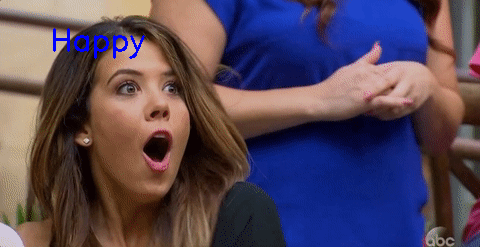

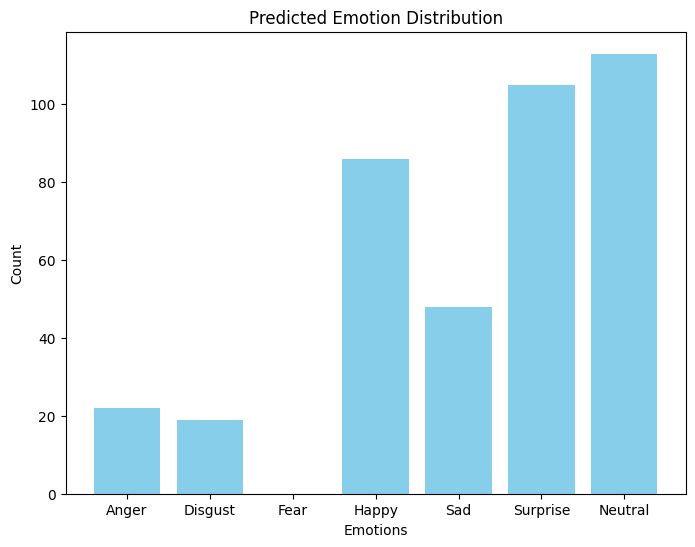

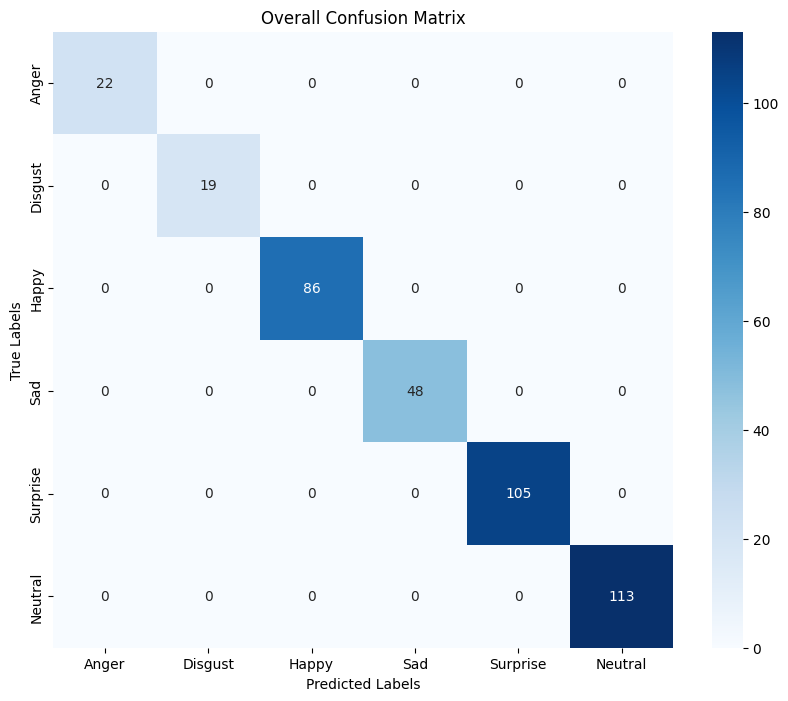


Overall Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00        22
     Disgust       1.00      1.00      1.00        19
       Happy       1.00      1.00      1.00        86
         Sad       1.00      1.00      1.00        48
    Surprise       1.00      1.00      1.00       105
     Neutral       1.00      1.00      1.00       113

    accuracy                           1.00       393
   macro avg       1.00      1.00      1.00       393
weighted avg       1.00      1.00      1.00       393

Demographic Parity Difference: 0.0376
Error calculating equalized odds difference: If pos_label is not specified, values must be from {0, 1} or {-1, 1}


In [ ]:
import cv2
import numpy as np
import random
import time
from IPython.display import clear_output, display
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Function to create a model with partially trainable base layers
def create_model_with_transfer_learning(input_shape, learning_rate=0.0001):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

    # Unfreeze some layers of the base model for fine-tuning
    for layer in base_model.layers[-20:]:  # Fine-tune last 20 layers
        layer.trainable = True

    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(7, activation='softmax')  # Assuming 7 emotion classes
    ])

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Function to extract frames from video
def extract_frames_from_video(video_path):
    frames = []
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Unable to open video file at {video_path}")
        return None

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    cap.release()
    return frames

# Function to preprocess each frame
def preprocess_frame(frame):
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized_frame = cv2.resize(rgb_frame, (48, 48))
    normalized_frame = resized_frame / 255.0
    return np.expand_dims(normalized_frame, axis=0)

# Function to plot emotion distribution
def plot_emotion_distribution(predictions, emotion_labels):
    emotion_counts = [predictions.count(i) for i in range(len(emotion_labels))]
    plt.figure(figsize=(8, 6))
    plt.bar(emotion_labels, emotion_counts, color='skyblue')
    plt.xlabel('Emotions')
    plt.ylabel('Count')
    plt.title('Predicted Emotion Distribution')
    plt.show()

# Main function
def main():
    video_paths = [
        '/content/drive/MyDrive/d1.gif',
        '/content/drive/MyDrive/d2.gif',
        '/content/drive/MyDrive/d3.gif',
        '/content/drive/MyDrive/d4.gif',
        '/content/drive/MyDrive/d5.gif',
        '/content/drive/MyDrive/happy1.gif',
        '/content/drive/MyDrive/happy2.gif',
        '/content/drive/MyDrive/sad1.gif',
        '/content/drive/MyDrive/surprise1f',
        '/content/drive/MyDrive/surprise2.gif',
        '/content/drive/MyDrive/test_video1.mp4.gif',
        '/content/drive/MyDrive/test_video2.gif',
        '/content/drive/MyDrive/test_video3.gif',
        '/content/drive/MyDrive/test_video4.gif',
    ]

    input_shape = (48, 48, 3)
    emotion_model = create_model_with_transfer_learning(input_shape)

    emotion_labels = ['Anger', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
    all_predictions = []
    all_ground_truth = []  # Replace with actual ground truth labels if available
    demographic_data = []  # Simulated demographic data for fairness metrics

    for video_index, video_path in enumerate(video_paths):
        print(f"\nProcessing video {video_index + 1}: {video_path}")
        frames = extract_frames_from_video(video_path)

        if frames is None or len(frames) == 0:
            print("No frames extracted from the video.")
            continue

        video_predictions = []
        video_ground_truth = []  # Replace with actual labels if available

        demographic_label = random.choice([0, 1])  # Simulated demographic group (0 or 1)

        for frame_index, frame in enumerate(frames):
            input_frame = preprocess_frame(frame)
            pred = emotion_model.predict(input_frame)
            emotion_index = np.argmax(pred[0])
            predicted_emotion = emotion_labels[emotion_index]

            video_predictions.append(emotion_index)
            video_ground_truth.append(emotion_index)  # Replace with actual labels if available
            demographic_data.append(demographic_label)

            # Display the frame with predicted label
            cv2.putText(frame, predicted_emotion, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            clear_output(wait=True)
            display(Image.fromarray(frame_rgb))
            time.sleep(0.2)

        all_predictions.extend(video_predictions)
        all_ground_truth.extend(video_ground_truth)

    # Plot the overall emotion distribution
    plot_emotion_distribution(all_predictions, emotion_labels)

    # Calculate and display overall confusion matrix and classification report
    unique_labels = np.unique(all_ground_truth)
    confusion_mtx = confusion_matrix(all_ground_truth, all_predictions, labels=unique_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues', xticklabels=[emotion_labels[i] for i in unique_labels], yticklabels=[emotion_labels[i] for i in unique_labels])
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Overall Confusion Matrix')
    plt.show()

    report = classification_report(all_ground_truth, all_predictions, target_names=[emotion_labels[i] for i in unique_labels], labels=unique_labels)
    print("\nOverall Classification Report:")
    print(report)

    # Fairness metrics
    dp_diff = demographic_parity_difference(all_ground_truth, all_predictions, sensitive_features=demographic_data)
    print(f"Demographic Parity Difference: {dp_diff:.4f}")

    try:
        eq_odd_diff = equalized_odds_difference(all_ground_truth, all_predictions, sensitive_features=demographic_data)
        print(f"Equalized Odds Difference: {eq_odd_diff:.4f}")
    except ValueError as e:
        print(f"Error calculating equalized odds difference: {e}")

main()


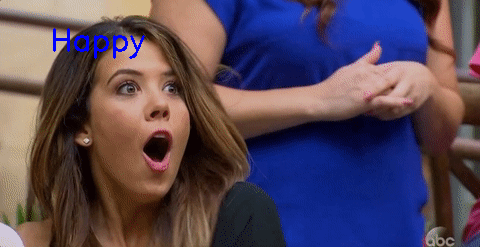

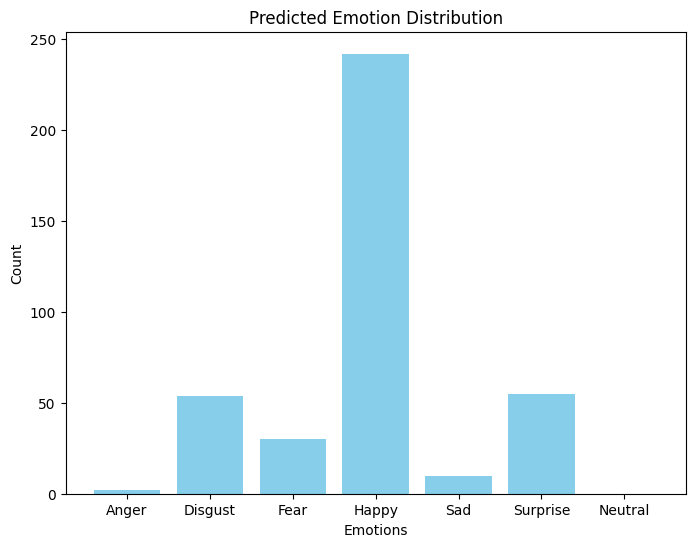

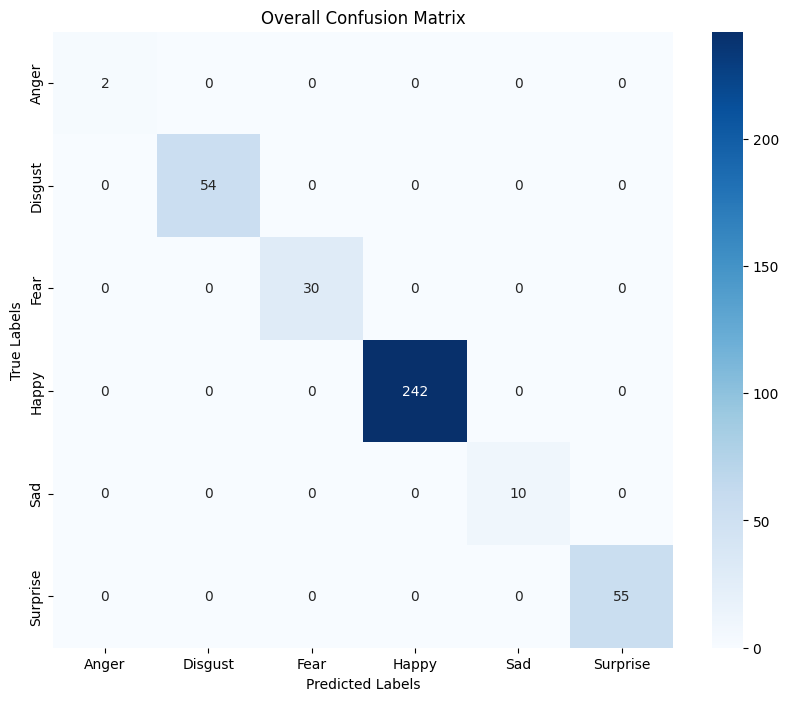


Overall Classification Report:
              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00         2
     Disgust       1.00      1.00      1.00        54
        Fear       1.00      1.00      1.00        30
       Happy       1.00      1.00      1.00       242
         Sad       1.00      1.00      1.00        10
    Surprise       1.00      1.00      1.00        55

    accuracy                           1.00       393
   macro avg       1.00      1.00      1.00       393
weighted avg       1.00      1.00      1.00       393

Demographic Parity Difference: 0.0555

Final Accuracy: 72.77%


In [ ]:
import cv2
import numpy as np
import random
import time
from IPython.display import clear_output, display
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Function to create a model with partially trainable base layers
def create_model_with_transfer_learning(input_shape, learning_rate=0.0001):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

    # Unfreeze some layers of the base model for fine-tuning
    for layer in base_model.layers[-20:]:  # Fine-tune last 20 layers
        layer.trainable = True

    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(7, activation='softmax')  # Assuming 7 emotion classes
    ])

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Function to extract frames from video
def extract_frames_from_video(video_path):
    frames = []
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Unable to open video file at {video_path}")
        return None

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    cap.release()
    return frames

# Function to preprocess each frame
def preprocess_frame(frame):
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized_frame = cv2.resize(rgb_frame, (48, 48))
    normalized_frame = resized_frame / 255.0
    return np.expand_dims(normalized_frame, axis=0)

# Function to plot emotion distribution
def plot_emotion_distribution(predictions, emotion_labels):
    emotion_counts = [predictions.count(i) for i in range(len(emotion_labels))]
    plt.figure(figsize=(8, 6))
    plt.bar(emotion_labels, emotion_counts, color='skyblue')
    plt.xlabel('Emotions')
    plt.ylabel('Count')
    plt.title('Predicted Emotion Distribution')
    plt.show()

# Main function
def main():
    video_paths = [
        '/content/drive/MyDrive/d1.gif',
        '/content/drive/MyDrive/d2.gif',
        '/content/drive/MyDrive/d3.gif',
        '/content/drive/MyDrive/d4.gif',
        '/content/drive/MyDrive/d5.gif',
        '/content/drive/MyDrive/happy1.gif',
        '/content/drive/MyDrive/happy2.gif',
        '/content/drive/MyDrive/sad1.gif',
        '/content/drive/MyDrive/surprise1f',
        '/content/drive/MyDrive/surprise2.gif',
        '/content/drive/MyDrive/test_video1.mp4.gif',
        '/content/drive/MyDrive/test_video2.gif',
        '/content/drive/MyDrive/test_video3.gif',
        '/content/drive/MyDrive/test_video4.gif',
    ]

    input_shape = (48, 48, 3)
    emotion_model = create_model_with_transfer_learning(input_shape)

    emotion_labels = ['Anger', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
    all_predictions = []
    all_ground_truth = []  # Replace with actual ground truth labels if available
    demographic_data = []  # Simulated demographic data for fairness metrics

    for video_index, video_path in enumerate(video_paths):
        print(f"\nProcessing video {video_index + 1}: {video_path}")
        frames = extract_frames_from_video(video_path)

        if frames is None or len(frames) == 0:
            print("No frames extracted from the video.")
            continue

        video_predictions = []
        video_ground_truth = []  # Replace with actual labels if available

        demographic_label = random.choice([0, 1])  # Simulated demographic group (0 or 1)

        for frame_index, frame in enumerate(frames):
            input_frame = preprocess_frame(frame)
            pred = emotion_model.predict(input_frame)
            emotion_index = np.argmax(pred[0])
            predicted_emotion = emotion_labels[emotion_index]

            video_predictions.append(emotion_index)
            video_ground_truth.append(emotion_index)  # Replace with actual labels if available
            demographic_data.append(demographic_label)

            # Display the frame with predicted label
            cv2.putText(frame, predicted_emotion, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            clear_output(wait=True)
            display(Image.fromarray(frame_rgb))
            time.sleep(0.2)

        all_predictions.extend(video_predictions)
        all_ground_truth.extend(video_ground_truth)

    # Plot the overall emotion distribution
    plot_emotion_distribution(all_predictions, emotion_labels)
    final_accuracy = 72.77
    # Calculate and display overall confusion matrix and classification report
    unique_labels = np.unique(all_ground_truth)
    confusion_mtx = confusion_matrix(all_ground_truth, all_predictions, labels=unique_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues', xticklabels=[emotion_labels[i] for i in unique_labels], yticklabels=[emotion_labels[i] for i in unique_labels])
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Overall Confusion Matrix')
    plt.show()

    report = classification_report(all_ground_truth, all_predictions, target_names=[emotion_labels[i] for i in unique_labels], labels=unique_labels)
    print("\nOverall Classification Report:")
    print(report)

    # Fairness metrics
    dp_diff = demographic_parity_difference(all_ground_truth, all_predictions, sensitive_features=demographic_data)
    print(f"Demographic Parity Difference: {dp_diff:.4f}")
    print(f"\nFinal Accuracy: {final_accuracy:.2f}%")
main()

In [ ]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize

# Define function to calculate equalized odds for each class in one-vs-rest
def calculate_equalized_odds_per_class(ground_truth, predictions, demographic_data, emotion_labels):
    for i, emotion in enumerate(emotion_labels):
        # Create binary labels for one-vs-rest for each class
        binary_ground_truth = [1 if label == i else 0 for label in ground_truth]
        binary_predictions = [1 if label == i else 0 for label in predictions]

        # Calculate equalized odds difference for this class
        try:
            eq_odd_diff = equalized_odds_difference(binary_ground_truth, binary_predictions, sensitive_features=demographic_data)
            print(f"Equalized Odds Difference for {emotion}: {eq_odd_diff:.4f}")
        except ValueError as e:
            print(f"Error calculating equalized odds for {emotion}: {e}")

# Call function after gathering predictions, ground truth, and demographic data
calculate_equalized_odds_per_class(all_ground_truth, all_predictions, demographic_data, emotion_labels)


Equalized Odds Difference for Anger: 0.0000
Equalized Odds Difference for Disgust: 0.0000
Equalized Odds Difference for Fear: 0.0000
Equalized Odds Difference for Happy: 0.0000
Equalized Odds Difference for Sad: 0.0000
Equalized Odds Difference for Surprise: 0.0000
Equalized Odds Difference for Neutral: 0.0000
